<a href="https://colab.research.google.com/github/diabateyoussouf/Segmentation-tumeurs-c-r-brales-IRM-avec-U-Net/blob/main/Projet_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **I. Segmentation simple :**

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import matplotlib.image as mpimg
from PIL import Image

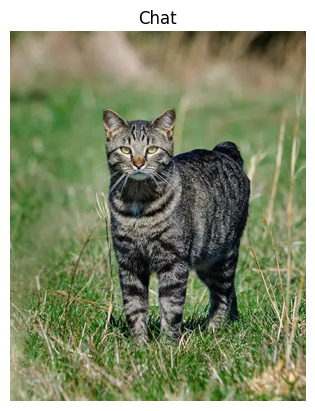

Shape: (530, 424, 3)
Type: uint8


In [57]:
url_img = "https://www.monde-des-chats.fr/wp-content/uploads/2019/11/Race-de-chat-manx.jpg"

# Télécharger l'image depuis l'URL
response = requests.get(url_img)
img = Image.open(BytesIO(response.content))

img_array = np.array(img)

# Afficher l'image
plt.imshow(img_array)
plt.axis('off')
plt.title("Chat")
plt.show()

# Afficher la taille et type de l'image
print("Shape:", img_array.shape)
print("Type:", img_array.dtype)


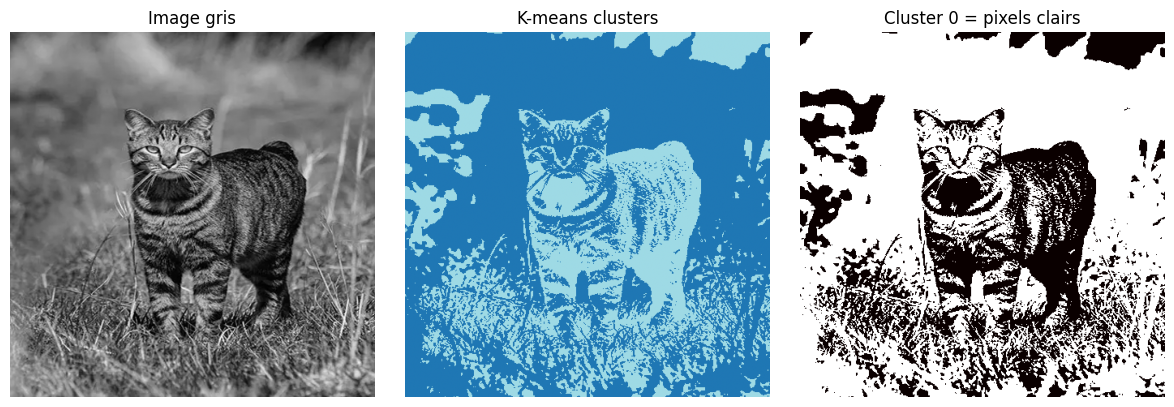

Clusters: [130.6072841   61.86988084]
Cluster le plus clair = 0 avec centre = 130.60728410487553


In [60]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 2. Redimensionner
img_small = img.resize((450, 450))
img_array = np.array(img_small)

gray = np.mean(img_array, axis=2).astype(int)

# 4. Préparer pour K-means
pixels = gray.reshape(-1, 1)

# 5. Appliquer K-means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(pixels)
segmented = labels.reshape(gray.shape)

# 6. Identifier le cluster avec les pixels les plus clairs (ou sombres)
centers = kmeans.cluster_centers_.flatten()
high_value_cluster = np.argmax(centers)
high_mask = (segmented == high_value_cluster).astype(int)

# 7. Visualiser
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Image gris')
axes[0].axis('off')

axes[1].imshow(segmented, cmap='tab20')
axes[1].set_title('K-means clusters')
axes[1].axis('off')

axes[2].imshow(high_mask, cmap='hot')
axes[2].set_title(f'Cluster {high_value_cluster} = pixels clairs')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 8. Infos
print("Clusters:", centers)
print("Cluster le plus clair =", high_value_cluster, "avec centre =", centers[high_value_cluster])

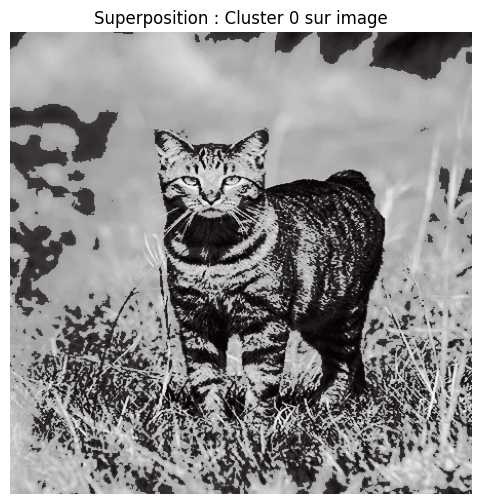

In [61]:
plt.figure(figsize=(6,6))
plt.imshow(gray, cmap='gray')
plt.imshow(high_mask, cmap='hot', alpha=0.4)
plt.title(f"Superposition : Cluster {high_value_cluster} sur image")
plt.axis('off')
plt.show()


#### tester avec vraie image de IRM

In [8]:
!mkdir -p /content/BraTS2021_00495

In [9]:
!tar -xvf /content/BraTS2021_00495.tar -C /content/BraTS2021_00495

./
./BraTS2021_00495_flair.nii.gz
./BraTS2021_00495_seg.nii.gz
./BraTS2021_00495_t1.nii.gz
./BraTS2021_00495_t1ce.nii.gz
./BraTS2021_00495_t2.nii.gz


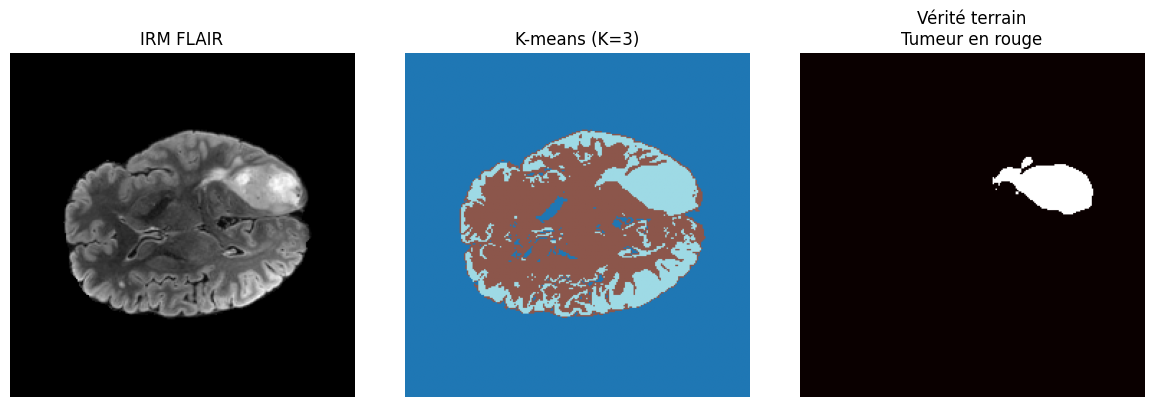

K-means centres: [  0  78 150]
Valeurs masque: [0. 1. 2. 4.]
K-means ne trouve pas la tumeur


In [10]:
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Charger IRM
flair_path = "/content/BraTS2021_00495/BraTS2021_00495_flair.nii.gz"
flair_data = nib.load(flair_path).get_fdata()
mri_slice = flair_data[:, :, 77]  # Slice 77

# K-means
mri_norm = (mri_slice - mri_slice.min()) / (mri_slice.max() - mri_slice.min())
mri_norm = (mri_norm * 255).astype(np.uint8)
pixels = mri_norm.reshape(-1, 1)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(pixels)
kmeans_result = labels.reshape(mri_slice.shape)

# Vérité terrain
seg_path = "/content/BraTS2021_00495/BraTS2021_00495_seg.nii.gz"
seg_data = nib.load(seg_path).get_fdata()
truth_slice = seg_data[:, :, 77]

# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(mri_slice, cmap='gray')
axes[0].set_title('IRM FLAIR')
axes[0].axis('off')

axes[1].imshow(kmeans_result, cmap='tab20')
axes[1].set_title('K-means (K=3)')
axes[1].axis('off')

axes[2].imshow(truth_slice > 0, cmap='hot')
axes[2].set_title('Vérité terrain\nTumeur en rouge')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("K-means centres:", kmeans.cluster_centers_.flatten().astype(int))
print("Valeurs masque:", np.unique(truth_slice))
print("K-means ne trouve pas la tumeur")

CONCLUSION : K-MEANS ÉCHOUE SUR IRM
============================================================

K-means :


*   Segmente par INTENSITÉ seulement
*   Ne comprend pas l'ANATOMIE
*   Échoue à trouver la tumeur
*   Élément de liste
→ SOLUTION : DEEP LEARNING (U-Net)

# **II. Segmentation tumeurs cérébrales IRM avec U‑Net**

### **II. 1. Prétraitement**

In [11]:
import numpy as np
import nibabel as nib
import cv2

### Visualisation

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_samples(X, y, slices=[60, 77, 90]):
    fig, axes = plt.subplots(len(slices), 3, figsize=(10, 3*len(slices)))

    for i, z in enumerate(slices):
        # IRM
        axes[i, 0].imshow(X[:, :, z], cmap='gray')
        axes[i, 0].set_title(f'FLAIR – slice {z}')
        axes[i, 0].axis('off')

        # Masque
        axes[i, 1].imshow(y[:, :, z] > 0, cmap='hot')
        axes[i, 1].set_title('Masque expert')
        axes[i, 1].axis('off')

        # Superposition
        axes[i, 2].imshow(X[:, :, z], cmap='gray')
        axes[i, 2].imshow(y[:, :, z] > 0, cmap='hot', alpha=0.3)
        axes[i, 2].set_title('Superposition')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


In [13]:
X = flair_data
y = seg_data

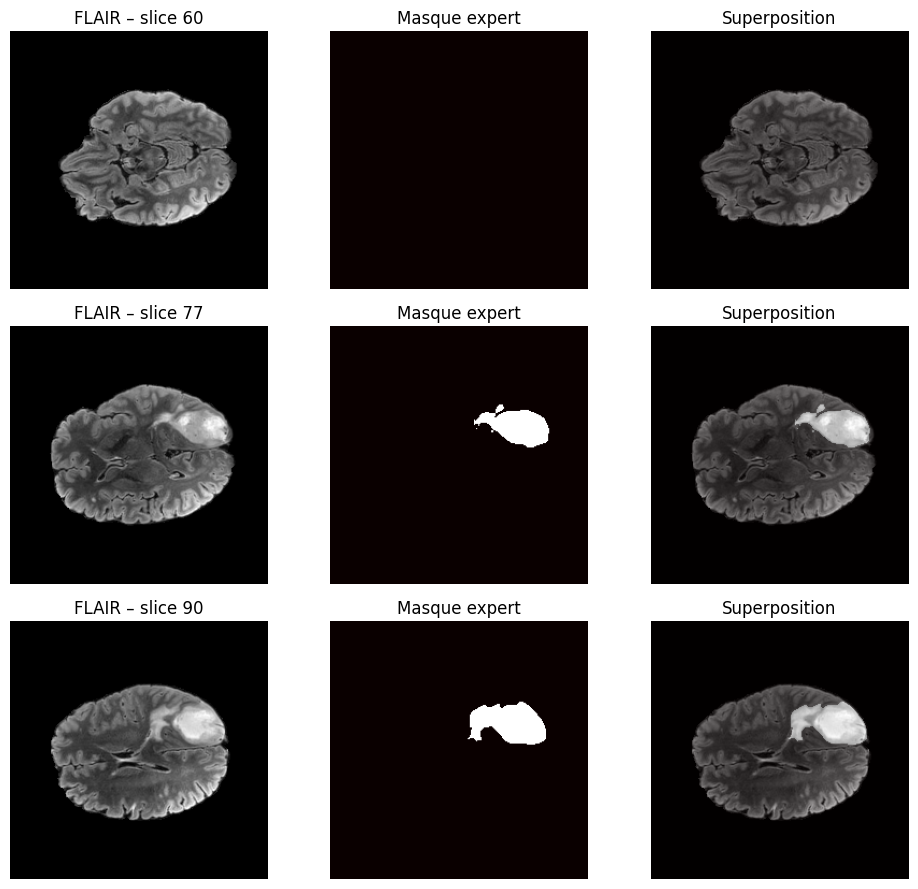

In [14]:
visualize_samples(X, y)

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
class BrainMRIPreprocessor:

    def __init__(self, target_size=(128, 128)):
        self.target_size = target_size

    def load_nifti(self, filepath):
        img = nib.load(filepath)
        return img.get_fdata().astype(np.float32)

    def normalize(self, data):
        data_min = np.min(data)
        data_max = np.max(data)
        if data_max > data_min:
            return (data - data_min) / (data_max - data_min)
        return np.zeros_like(data)

    def resize(self, data):
        return cv2.resize(data, self.target_size, interpolation=cv2.INTER_AREA)

    def preprocess_slice(self, slice_data):
        normalized = self.normalize(slice_data)
        resized = self.resize(normalized)
        return np.expand_dims(resized, axis=-1)

    def prepare_patient(self, flair_path, seg_path, t1_path=None, t1ce_path=None, t2_path=None):

        flair_data = self.load_nifti(flair_path)
        seg_data = self.load_nifti(seg_path)

        modalities_data = [flair_data]

        if t1_path:
            t1_data = self.load_nifti(t1_path)
            modalities_data.append(t1_data)

        if t1ce_path:
            t1ce_data = self.load_nifti(t1ce_path)
            modalities_data.append(t1ce_data)

        if t2_path:
            t2_data = self.load_nifti(t2_path)
            modalities_data.append(t2_data)

        X_list, y_list = [], []

        for i in range(flair_data.shape[2]):
            flair_slice = flair_data[:, :, i]
            seg_slice = seg_data[:, :, i]

            if np.sum(seg_slice > 0) < 10:
                continue

            # Prétraiter toutes les modalités pour cette slice
            processed_channels = []

            for modality_data in modalities_data:
                modality_slice = modality_data[:, :, i]
                processed_channel = self.preprocess_slice(modality_slice)
                processed_channels.append(processed_channel)

            X_processed = np.concatenate(processed_channels, axis=-1)

            # Prétraiter la segmentation
            seg_binary = (seg_slice > 0).astype(np.float32)
            seg_resized = self.resize(seg_binary)
            y_processed = np.expand_dims(seg_resized, axis=-1)

            X_list.append(X_processed)
            y_list.append(y_processed)

        return np.array(X_list), np.array(y_list)

    def split_dataset(self, X, y, test_size=0.2, val_size=0.1):
        # Train/Test
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        # Train/Val
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=val_size, random_state=42
        )

        return X_train, X_val, X_test, y_train, y_val, y_test

In [17]:
# Initialiser le preprocesseur
preprocessor = BrainMRIPreprocessor(target_size=(128, 128))

# Utiliser avec toutes les modalités
X, y = preprocessor.prepare_patient(
    flair_path="/content/BraTS2021_00495/BraTS2021_00495_flair.nii.gz",
    seg_path="/content/BraTS2021_00495/BraTS2021_00495_seg.nii.gz",
    t1_path="//content/BraTS2021_00495/BraTS2021_00495_t1.nii.gz",
    t1ce_path="/content/BraTS2021_00495/BraTS2021_00495_t1ce.nii.gz",
    t2_path="/content/BraTS2021_00495/BraTS2021_00495_t2.nii.gz"
)

# Vérifier la shape
print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Diviser le dataset
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.split_dataset(X, y)
print(f"Shape de X train: {X_train.shape}")
print(f"Shape de y train: {y_train.shape}")
print(f"Shape de X test: {X_test.shape}")
print(f"Shape de y test : {y_test.shape}")


Shape de X: (69, 128, 128, 4)
Shape de y: (69, 128, 128, 1)
Shape de X train: (49, 128, 128, 4)
Shape de y train: (49, 128, 128, 1)
Shape de X test: (14, 128, 128, 4)
Shape de y test : (14, 128, 128, 1)


### II. 2. Constructions des modèles UNET

#  Construction de l'U-Net

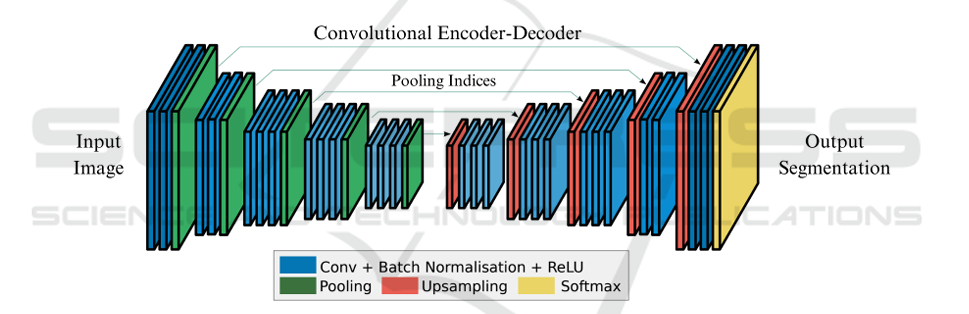

In [18]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


def build_unet(input_shape=(128, 128, 4)):

    # Entrée  avec 4 canaux
    inputs = layers.Input(shape=input_shape)

    # ENCODEUR
    # Bloc 1
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    # Bloc 2
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Bloc 3
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # CENTRE
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)

    # DÉCODEUR
    # Bloc 1
    up5 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv4)
    concat5 = layers.Concatenate()([up5, conv3])  # Skip connection
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(concat5)
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv5)

    # Bloc 2
    up6 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv5)
    concat6 = layers.Concatenate()([up6, conv2])  # Skip connection
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat6)
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv6)

    # Bloc 3
    up7 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv6)
    concat7 = layers.Concatenate()([up7, conv1])  # Skip connection
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat7)
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv7)

    # SORTIE
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    # Modèle
    model = Model(inputs=inputs, outputs=outputs, name='U_Net_MultiModal')
    return model

## Fonctions de perte et métriques

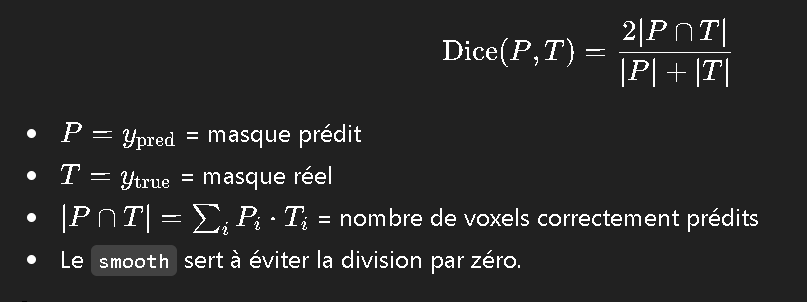

In [62]:
# Fonctions de métriques
def dice_coefficient(y_true, y_pred, smooth=1e-6):

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    dice = (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )
    return dice

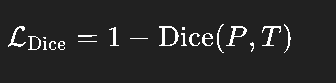

In [31]:
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

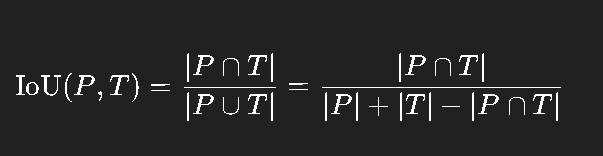

In [63]:
def iou_metric(y_true, y_pred, smooth=1e-6):

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

### Compilation du modèle

In [21]:
def compile_model(model, learning_rate=1e-4):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=dice_loss,
        metrics=[
            'accuracy',
            dice_coefficient,
            iou_metric,
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model

### Entraînement du modèle

In [22]:
def train_model_with_callbacks(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=8):

    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_dice_coefficient',
            patience=15,
            mode='max',
            verbose=1,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            'best_brain_segmentation_model.h5',
            monitor='val_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        )
    ]


    # Entraînement
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=True
    )

    return history


In [23]:
model = build_unet(input_shape=(128, 128, 4))
model = compile_model(model, learning_rate=1e-4)

In [24]:
model.summary()

Model: "U_Net_MultiModal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    524,544 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  1,179,904 │ concatenate[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 64, 64,    │    131,200 │ conv2d_9[0][0]  

 Total params: 7,697,921 (29.37 MB)

 Trainable params: 7,697,921 (29.37 MB)

 Non-trainable params: 0 (0.00 B)

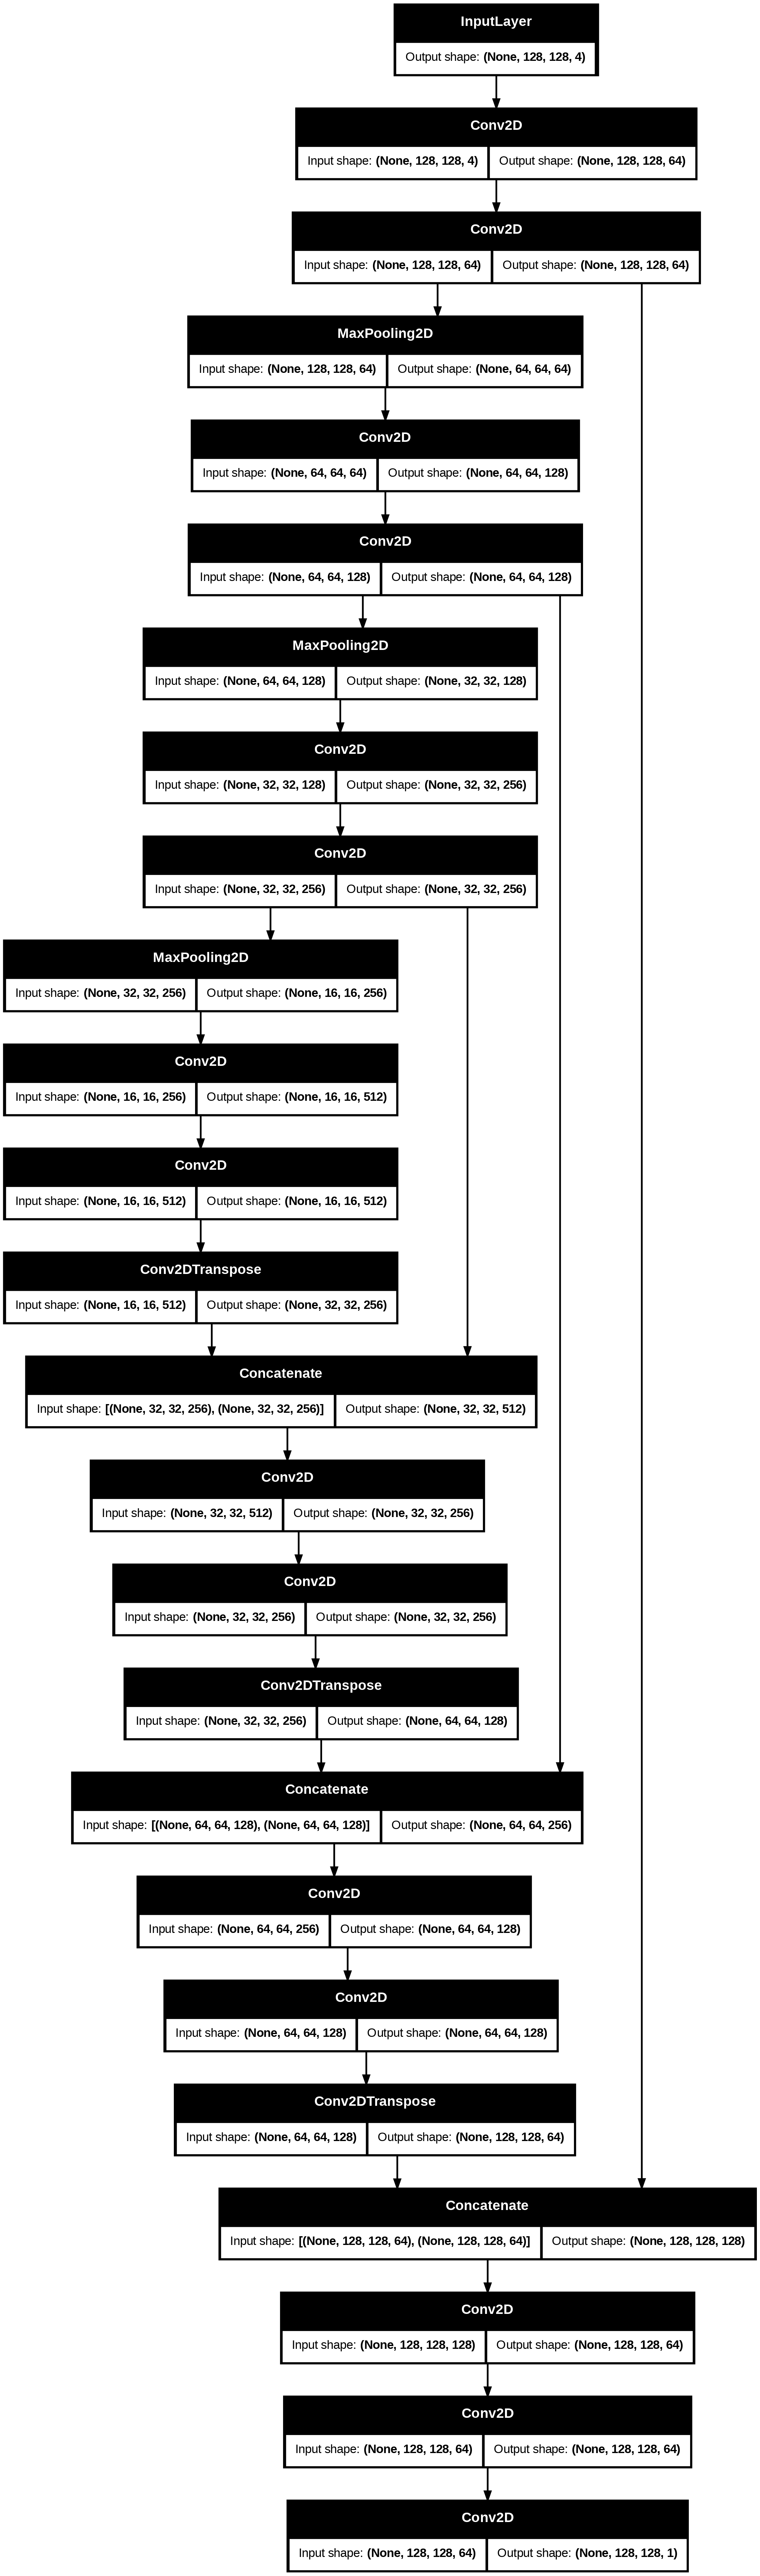

In [65]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes=True)

In [25]:
print("\n" + "="*60)
history = train_model_with_callbacks(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=50,
        batch_size=8
    )


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1603 - dice_coefficient: 0.0492 - iou_metric: 0.0252 - loss: 0.9506 - precision: 0.0141 - recall: 0.4288   
Epoch 1: val_dice_coefficient improved from -inf to 0.05600, saving model to best_brain_segmentation_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.1566 - dice_coefficient: 0.0487 - iou_metric: 0.0250 - loss: 0.9508 - precision: 0.0152 - recall: 0.4613 - val_accuracy: 0.3232 - val_dice_coefficient: 0.0560 - val_iou_metric: 0.0288 - val_loss: 0.9440 - val_precision: 0.0461 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.4774 - dice_coefficient: 0.0471 - iou_metric: 0.0241 - loss: 0.9529 - precision: 0.0508 - recall: 1.0000
Epoch 2: val_dice_coefficient improved from 0.05600 to 0.06120, saving model to best_brain_segmentation_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.4951 - dice_coefficient: 0.0486 - iou_metric: 0.0249 - loss: 0.9519 - precision: 0.0534 - recall: 1.0000 - val_accuracy: 0.6078 - val_dice_coefficient: 0.0612 - val_iou_metric: 0.0316 - val_loss: 0.9388 - val_precision: 0.0785 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6241 - dice_coefficient: 0.0566 - iou_metric: 0.0292 - loss: 0.9434 - precision: 0.0742 - recall: 1.0000
Epoch 3: val_dice_coefficient improved from 0.06120 to 0.07429, saving model to best_brain_segmentation_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.6218 - dice_coefficient: 0.0578 - iou_metric: 0.0298 - loss: 0.9431 - precision: 0.0736 - recall: 1.0000 - val_accuracy: 0.5298 - val_dice_coefficient: 0.0743 - val_iou_metric: 0.0386 - val_loss: 0.9257 - val_precision: 0.0658 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5272 - dice_coefficient: 0.0675 - iou_metric: 0.0349 - loss: 0.9325 - precision: 0.0572 - recall: 1.0000
Epoch 4: val_dice_coefficient improved from 0.07429 to 0.08219, saving model to best_brain_segmentation_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5230 - dice_coefficient: 0.0689 - iou_metric: 0.0357 - loss: 0.9316 - precision: 0.0571 - recall: 1.0000 - val_accuracy: 0.4801 - val_dice_coefficient: 0.0822 - val_iou_metric: 0.0429 - val_loss: 0.9178 - val_precision: 0.0597 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.5472 - dice_coefficient: 0.0712 - iou_metric: 0.0369 - loss: 0.9288 - precision: 0.0588 - recall: 1.0000
Epoch 5: val_dice_coefficient improved from 0.08219 to 0.08527, saving model to best_brain_segmentation_model.h5


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9783 - dice_coefficient: 0.8272 - iou_metric: 0.7064 - loss: 0.1750 - precision: 0.8376 - recall: 0.8424 - val_accuracy: 0.9774 - val_dice_coefficient: 0.8606 - val_iou_metric: 0.7554 - val_loss: 0.1394 - val_precision: 0.8671 - val_recall: 0.8806 - learning_rate: 1.0000e-04
Epoch 15/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9781 - dice_coefficient: 0.8530 - iou_metric: 0.7444 - loss: 0.1470 - precision: 0.8680 - recall: 0.8582
Epoch 15: val_dice_coefficient did not improve from 0.86064
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9784 - dice_coefficient: 0.8485 - iou_metric: 0.7378 - loss: 0.1494 - precision: 0.8694 - recall: 0.8521 - val_accuracy: 0.9790 - val_dice_coefficient: 0.8297 - val_iou_metric: 0.7089 - val_loss: 0.1703 - val_precision: 0.9609 - val_recall: 0.6831 - learning_rate: 1.0000e-04
Epoch 16/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9808 - dice_coefficient: 0.8327 - iou_metric: 0.71

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.9805 - dice_coefficient: 0.8377 - iou_metric: 0.7214 - loss: 0.1640 - precision: 0.9068 - recall: 0.7657 - val_accuracy: 0.9794 - val_dice_coefficient: 0.8770 - val_iou_metric: 0.7810 - val_loss: 0.1230 - val_precision: 0.9395 - val_recall: 0.7980 - learning_rate: 1.0000e-04
Epoch 17/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9809 - dice_coefficient: 0.8642 - iou_metric: 0.7613 - loss: 0.1358 - precision: 0.9109 - recall: 0.8225
Epoch 17: val_dice_coefficient did not improve from 0.87702
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9808 - dice_coefficient: 0.8561 - iou_metric: 0.7514 - loss: 0.1358 - precision: 0.9104 - recall: 0.8264 - val_accuracy: 0.9768 - val_dice_coefficient: 0.6977 - val_iou_metric: 0.5357 - val_loss: 0.3023 - val_precision: 0.9908 - val_recall: 0.4794 - learning_rate: 1.0000e-04
Epoch 18/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9773 - dice_coefficient: 0.7127 - iou_metric: 0.56

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.9804 - dice_coefficient: 0.8699 - iou_metric: 0.7706 - loss: 0.1318 - precision: 0.9214 - recall: 0.8155 - val_accuracy: 0.9797 - val_dice_coefficient: 0.8921 - val_iou_metric: 0.8051 - val_loss: 0.1079 - val_precision: 0.9398 - val_recall: 0.8315 - learning_rate: 1.0000e-04
Epoch 22/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9814 - dice_coefficient: 0.8789 - iou_metric: 0.7845 - loss: 0.1211 - precision: 0.9330 - recall: 0.8233
Epoch 22: val_dice_coefficient did not improve from 0.89206
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9814 - dice_coefficient: 0.8797 - iou_metric: 0.7857 - loss: 0.1213 - precision: 0.9344 - recall: 0.8213 - val_accuracy: 0.9790 - val_dice_coefficient: 0.8915 - val_iou_metric: 0.8042 - val_loss: 0.1085 - val_precision: 0.9076 - val_recall: 0.9058 - learning_rate: 1.0000e-04
Epoch 23/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9804 - dice_coefficient: 0.8750 - iou_metric: 0.77

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.9806 - dice_coefficient: 0.8769 - iou_metric: 0.7811 - loss: 0.1243 - precision: 0.9039 - recall: 0.8741 - val_accuracy: 0.9799 - val_dice_coefficient: 0.8994 - val_iou_metric: 0.8173 - val_loss: 0.1006 - val_precision: 0.9403 - val_recall: 0.8589 - learning_rate: 1.0000e-04
Epoch 24/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9811 - dice_coefficient: 0.8786 - iou_metric: 0.7843 - loss: 0.1214 - precision: 0.9108 - recall: 0.8757
Epoch 24: val_dice_coefficient improved from 0.89944 to 0.90292, saving model to best_brain_segmentation_model.h5


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - accuracy: 0.9811 - dice_coefficient: 0.8796 - iou_metric: 0.7859 - loss: 0.1209 - precision: 0.9139 - recall: 0.8698 - val_accuracy: 0.9800 - val_dice_coefficient: 0.9029 - val_iou_metric: 0.8230 - val_loss: 0.0971 - val_precision: 0.9428 - val_recall: 0.8631 - learning_rate: 1.0000e-04
Epoch 25/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9812 - dice_coefficient: 0.8921 - iou_metric: 0.8055 - loss: 0.1079 - precision: 0.9243 - recall: 0.8798
Epoch 25: val_dice_coefficient did not improve from 0.90292
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9812 - dice_coefficient: 0.8901 - iou_metric: 0.8022 - loss: 0.1089 - precision: 0.9249 - recall: 0.8764 - val_accuracy: 0.9800 - val_dice_coefficient: 0.8660 - val_iou_metric: 0.7636 - val_loss: 0.1340 - val_precision: 0.9877 - val_recall: 0.7156 - learning_rate: 1.0000e-04
Epoch 26/50
6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9805 - dice_coefficient: 0.8626 - iou_metric: 0.75

In [26]:
print("\n ÉVALUATION FINALE")
test_results = model.evaluate(X_val, y_val, verbose=0)

print(f"Dice coefficient sur validation: {test_results[2]:.4f}")
print(f"IoU sur validation: {test_results[3]:.4f}")
print(f"Précision: {test_results[4]:.4f}")
print(f"Rappel: {test_results[5]:.4f}")


 ÉVALUATION FINALE
Dice coefficient sur validation: 0.9029
IoU sur validation: 0.8230
Précision: 0.9428
Rappel: 0.8631


#### Foncion display courbes

In [27]:
def curve(history, metric_name):
  plt.plot(history.history[metric_name], label=metric_name)
  plt.plot(history.history[f'val_{metric_name}'], label=f'val_{metric_name}')
  plt.xlabel('Epochs')
  plt.ylabel(metric_name)
  plt.legend()
  plt.show()

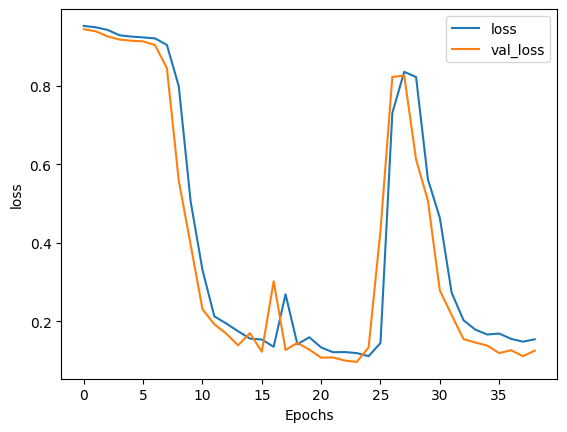

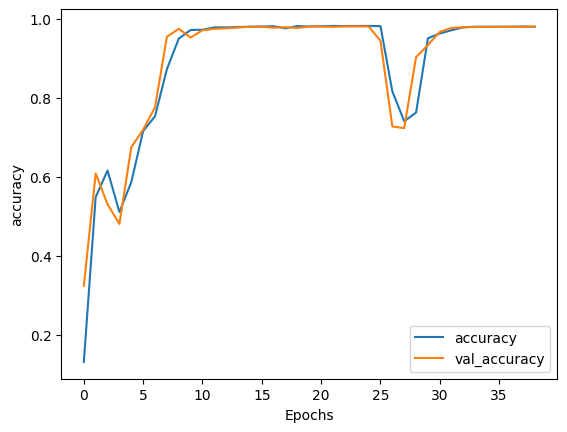

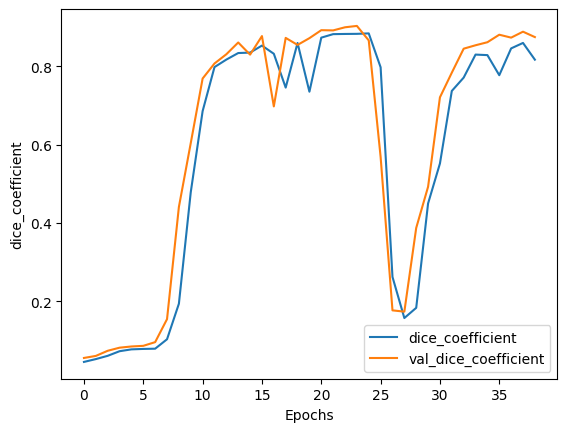

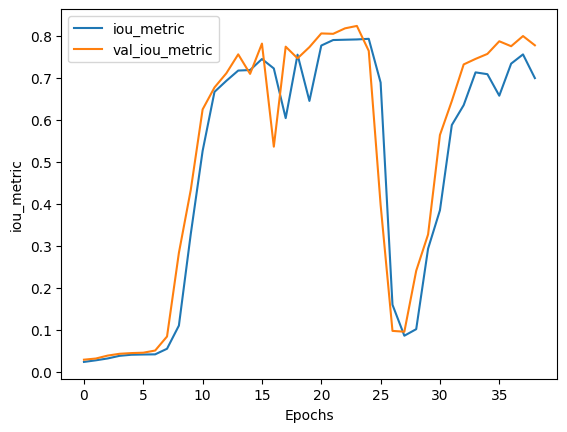

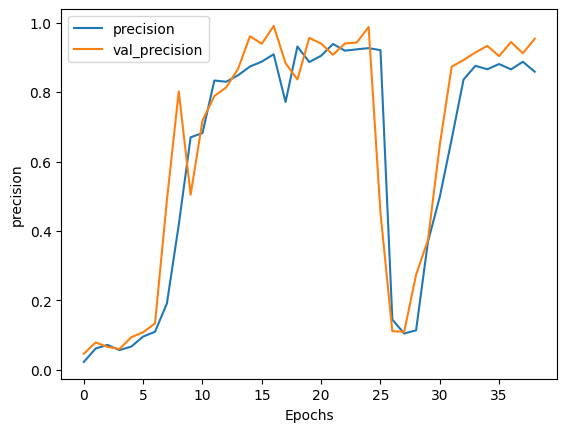

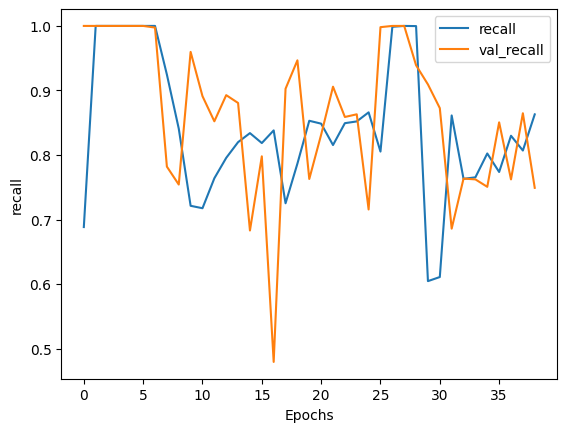

In [30]:
curve(history, 'loss')
curve(history, 'accuracy')
curve(history, 'dice_coefficient')
curve(history, 'iou_metric')
curve(history, 'precision')
curve(history, 'recall')

In [28]:
def visualize_predictions(model, X_samples, y_true, num_samples=3):
        import matplotlib.pyplot as plt

        predictions = model.predict(X_samples[:num_samples])

        fig, axes = plt.subplots(num_samples, 4, figsize=(15, 4*num_samples))

        for i in range(num_samples):
            # Modalité FLAIR (canal 0)
            axes[i, 0].imshow(X_samples[i, :, :, 0], cmap='gray')
            axes[i, 0].set_title(f'Slice {i} - FLAIR')
            axes[i, 0].axis('off')

            # Vérité terrain
            axes[i, 1].imshow(y_true[i].squeeze(), cmap='hot')
            axes[i, 1].set_title('Vérité terrain')
            axes[i, 1].axis('off')

            # Prédiction
            axes[i, 2].imshow(predictions[i].squeeze(), cmap='hot')
            axes[i, 2].set_title('Prédiction')
            axes[i, 2].axis('off')

            # Superposition
            axes[i, 3].imshow(X_samples[i, :, :, 0], cmap='gray', alpha=0.7)
            axes[i, 3].imshow(predictions[i].squeeze(), cmap='hot', alpha=0.3)
            axes[i, 3].set_title('Superposition')
            axes[i, 3].axis('off')

        plt.tight_layout()
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


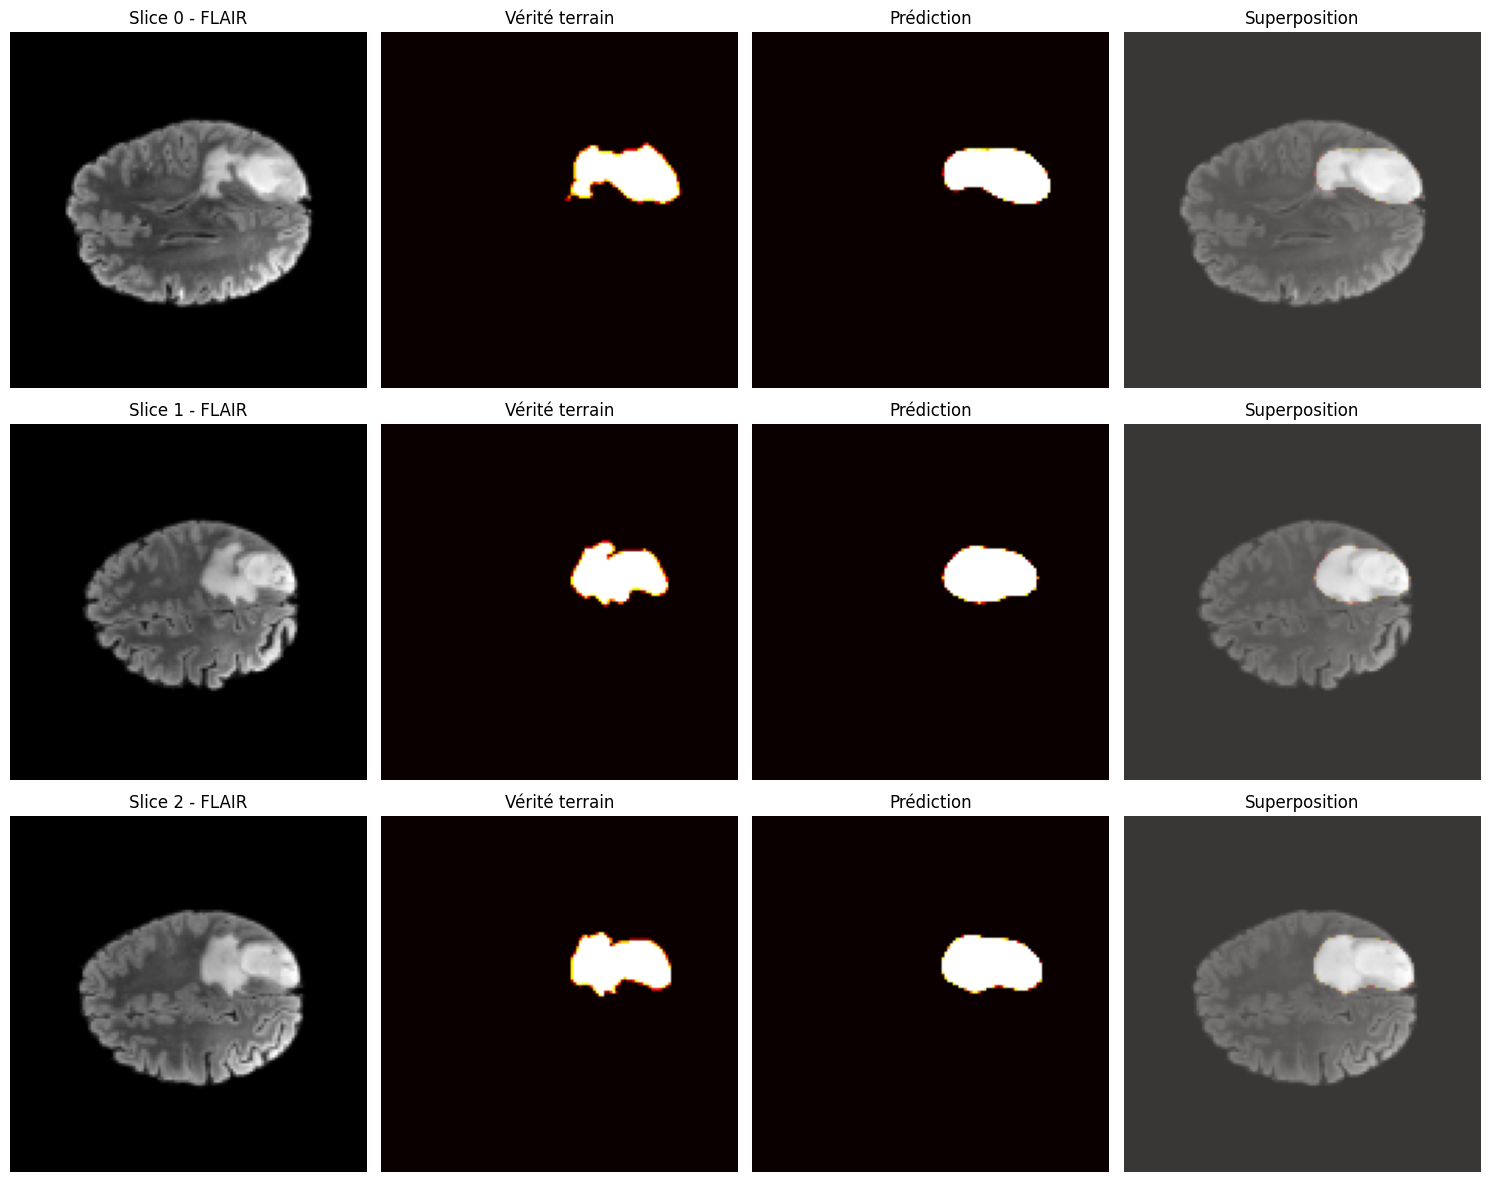

In [29]:
# Visualiser quelques prédictions
visualize_predictions(model, X_val[:3], y_val[:3])